In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform

# 1. توليد إحداثيات عشوائية لـ 30 بئر في الحقل (X, Y بالامتار) مع قيم المسامية (Porosity)
np.random.seed(42)
X = np.random.uniform(0, 2000, 30)  # أبعاد الحقل 2 كم
Y = np.random.uniform(0, 2000, 30)
Porosity = np.random.normal(0.18, 0.04, 30)  # متوسط مسامية 18%

wells_df = pd.DataFrame({'Well_X': X, 'Well_Y': Y, 'Porosity': Porosity})

# 2. حساب المسافات البينية بين كل الآبار (Distance Matrix)
coords = wells_df[['Well_X', 'Well_Y']].values
dist_matrix = squareform(pdist(coords))

# 3. حساب التباين في المسامية (Semivariance) بين كل بئرين
poro_values = wells_df['Porosity'].values
poro_diff_matrix = squareform(pdist(poro_values.reshape(-1, 1)))**2 / 2

print("🌐 تم تحديد مواقع الآبار في الفراغ الجيولوجي، وحساب مصفوفات المسافات والتباين المكاني!")
print(wells_df.head())

🌐 تم تحديد مواقع الآبار في الفراغ الجيولوجي، وحساب مصفوفات المسافات والتباين المكاني!
        Well_X       Well_Y  Porosity
0   749.080238  1215.089704  0.120859
1  1901.428613   341.048247  0.151206
2  1463.987884   130.103186  0.161574
3  1197.316968  1897.771075  0.222285
4   312.037281  1931.264066  0.193745


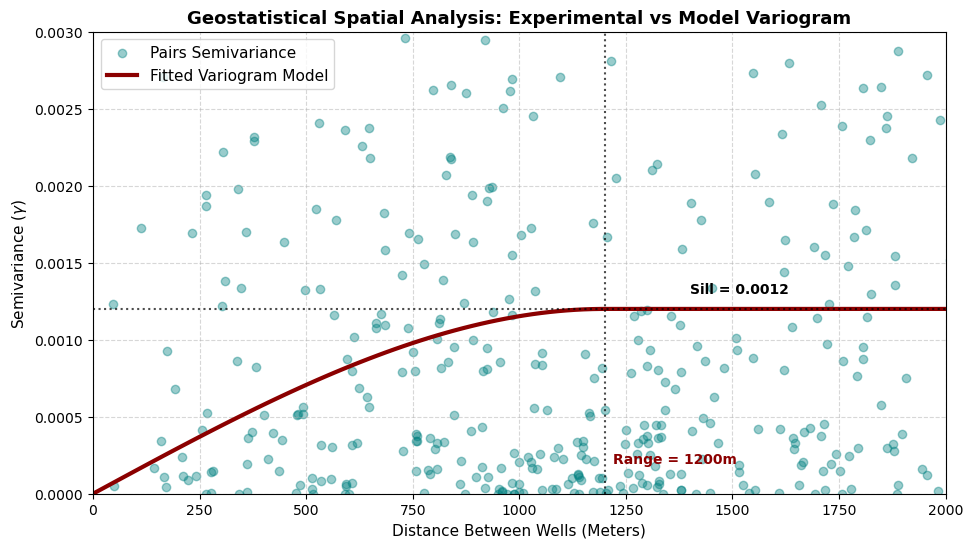

In [2]:
# 1. استخراج القيم من المصفوفات لتحويلها إلى قراءات خطية (Flattening)
# نأخذ المثلث العلوي للمصفوفات لتجنب التكرار والمسافة صفر مع البئر ونفسه
tri_indices = np.triu_indices(30, k=1)
flat_distances = dist_matrix[tri_indices]
flat_variance = poro_diff_matrix[tri_indices]

# 2. إنشاء لوحة الرسم الهندسي
plt.figure(figsize=(11, 6))

# رسم النقاط الحقيقية للتباين بين كل بئرين (Variogram Cloud)
plt.scatter(flat_distances, flat_variance, color='teal', alpha=0.4, label='Pairs Semivariance')

# 3. رسم خط نموذجي افتراضي (Spherical Model) لتوضيح الـ Range والـ Sill هندسياً
# لنفرض أن الـ Range = 1200 متر والـ Sill = 0.0012
mock_range = 1200
mock_sill = 0.0012
x_model = np.linspace(0, 2000, 100)
y_model = np.where(x_model <= mock_range, 
                   mock_sill * (1.5 * (x_model/mock_range) - 0.5 * (x_model/mock_range)**3), 
                   mock_sill)

plt.plot(x_model, y_model, color='darkred', linewidth=3, label='Fitted Variogram Model')

# 4. إضافة علامات الـ Range والـ Sill على الرسمة
plt.axhline(y=mock_sill, color='black', linestyle=':', alpha=0.7)
plt.text(1400, mock_sill + 0.0001, f'Sill = {mock_sill}', fontsize=10, fontweight='bold', color='black')

plt.axvline(x=mock_range, color='black', linestyle=':', alpha=0.7)
plt.text(mock_range + 20, 0.0002, f'Range = {mock_range}m', fontsize=10, fontweight='bold', color='darkred')

# 5. اللمسات النهائية اللائقة بالتقارير النفطية
plt.title('Geostatistical Spatial Analysis: Experimental vs Model Variogram', fontsize=13, fontweight='bold')
plt.xlabel('Distance Between Wells (Meters)', fontsize=11)
plt.ylabel('Semivariance ($\gamma$)', fontsize=11)
plt.xlim(0, 2000)
plt.ylim(0, 0.003)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11, loc='upper left')

plt.show()